# 07 — Final inference (refactored)

Ce notebook charge le meilleur checkpoint binaire depuis `artifacts/checkpoints/` et évalue le modèle sur le dossier `Testing`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /home/alouiyaz/projects/PINKCC/Brain_tumor_MRI_classification


In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from brain_tumor_mri.data.dataset import BrainMRIDataset
from brain_tumor_mri.data.loaders import make_loaders
from brain_tumor_mri.data.transforms import get_eval_transforms
from brain_tumor_mri.models.resnet18 import build_resnet18
from brain_tumor_mri.training.engine import validate_one_epoch
from brain_tumor_mri.evaluation.metrics import compute_metrics
from brain_tumor_mri.utils import get_device, load_checkpoint

device = get_device()
print("Device:", device)

Device: cpu


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0

TEST_DIR = PROJECT_ROOT / "data/raw/brain_mri/Testing"
MODEL_PATH = PROJECT_ROOT / "artifacts/checkpoints/best_resnet18_train_testing_split.pt"

test_tfms = get_eval_transforms(img_size=IMG_SIZE)
test_dataset = BrainMRIDataset(TEST_DIR, transform=test_tfms)

_, test_loader = make_loaders(
    test_dataset,
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    weighted=False,
    pin_memory=(device.type == "cuda"),
)

print("Test size:", len(test_dataset))
print("Model path exists:", MODEL_PATH.exists())

Test size: 394
Model path exists: True


In [4]:
model = build_resnet18(num_classes=2, pretrained=False)
model = load_checkpoint(model, MODEL_PATH, map_location=device)
model = model.to(device)

results = validate_one_epoch(model, test_loader, nn.CrossEntropyLoss(), device)
metrics = compute_metrics(y_true=results["targets"], y_pred=results["preds"])

print(metrics["classification_report"])
print("Confusion matrix:\n", metrics["confusion_matrix"])

              precision    recall  f1-score   support

           0     0.7609    1.0000    0.8642       105
           1     1.0000    0.8858    0.9394       289

    accuracy                         0.9162       394
   macro avg     0.8804    0.9429    0.9018       394
weighted avg     0.9363    0.9162    0.9194       394

Confusion matrix:
 [[105   0]
 [ 33 256]]


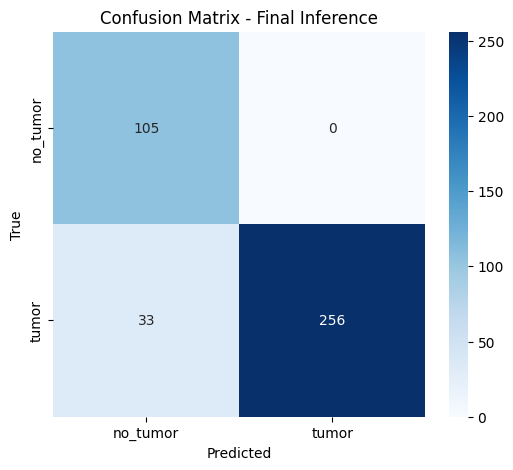

In [5]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    metrics["confusion_matrix"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["no_tumor", "tumor"],
    yticklabels=["no_tumor", "tumor"],
)
plt.title("Confusion Matrix - Final Inference")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()